# [LAB-10] 1-2. 로지스틱회귀 모듈화

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
# 라이브러리 기본 참조
from jussam import load_data
from helper import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('iris_bin')
origin.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)



,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,versicolor
1,6.400,3.200,4.500,1.500,versicolor
2,6.900,3.100,4.900,1.500,versicolor
3,5.500,2.300,4.000,1.300,versicolor
4,6.500,2.800,4.600,1.500,versicolor


### 3. 데이터 전처리

In [3]:
df = origin[['Sepal_Length', 'Species']]
df = my_prep.labeling(df, columns=['Species'])
df.head()

Species (2종): versicolor=0, virginica=1


,Sepal_Length,Species
0,7.000,0
1,6.400,0
2,6.900,0
3,5.500,0
4,6.500,0


## #02. 모듈화 기능 확인

### 1. 로지스틱 모델 적합

In [4]:
fit = my_logit.fit_model(df, y='Species', summary=True)

                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        12:22:24   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129      0.465      4.325      0.000       1.101       2.925


### 2. 예측값 생성

In [5]:
pred = my_logit.predict(fit, df[['Sepal_Length']])

new_df = df.copy()
new_df[['proba', 'pred']] = pred

new_df.head()

,Sepal_Length,Species,proba,pred
0,7.000,0,0.820,1
1,6.400,0,0.577,1
2,6.900,0,0.789,1
3,5.500,0,0.182,0
4,6.500,0,0.626,1


### 3. 시그모이드 곡선 시각화

`plot_sigmoid()`는 관측치 산점도 · S자 곡선 · 임계값 · 분류 경계를 한 번에 그려준다.

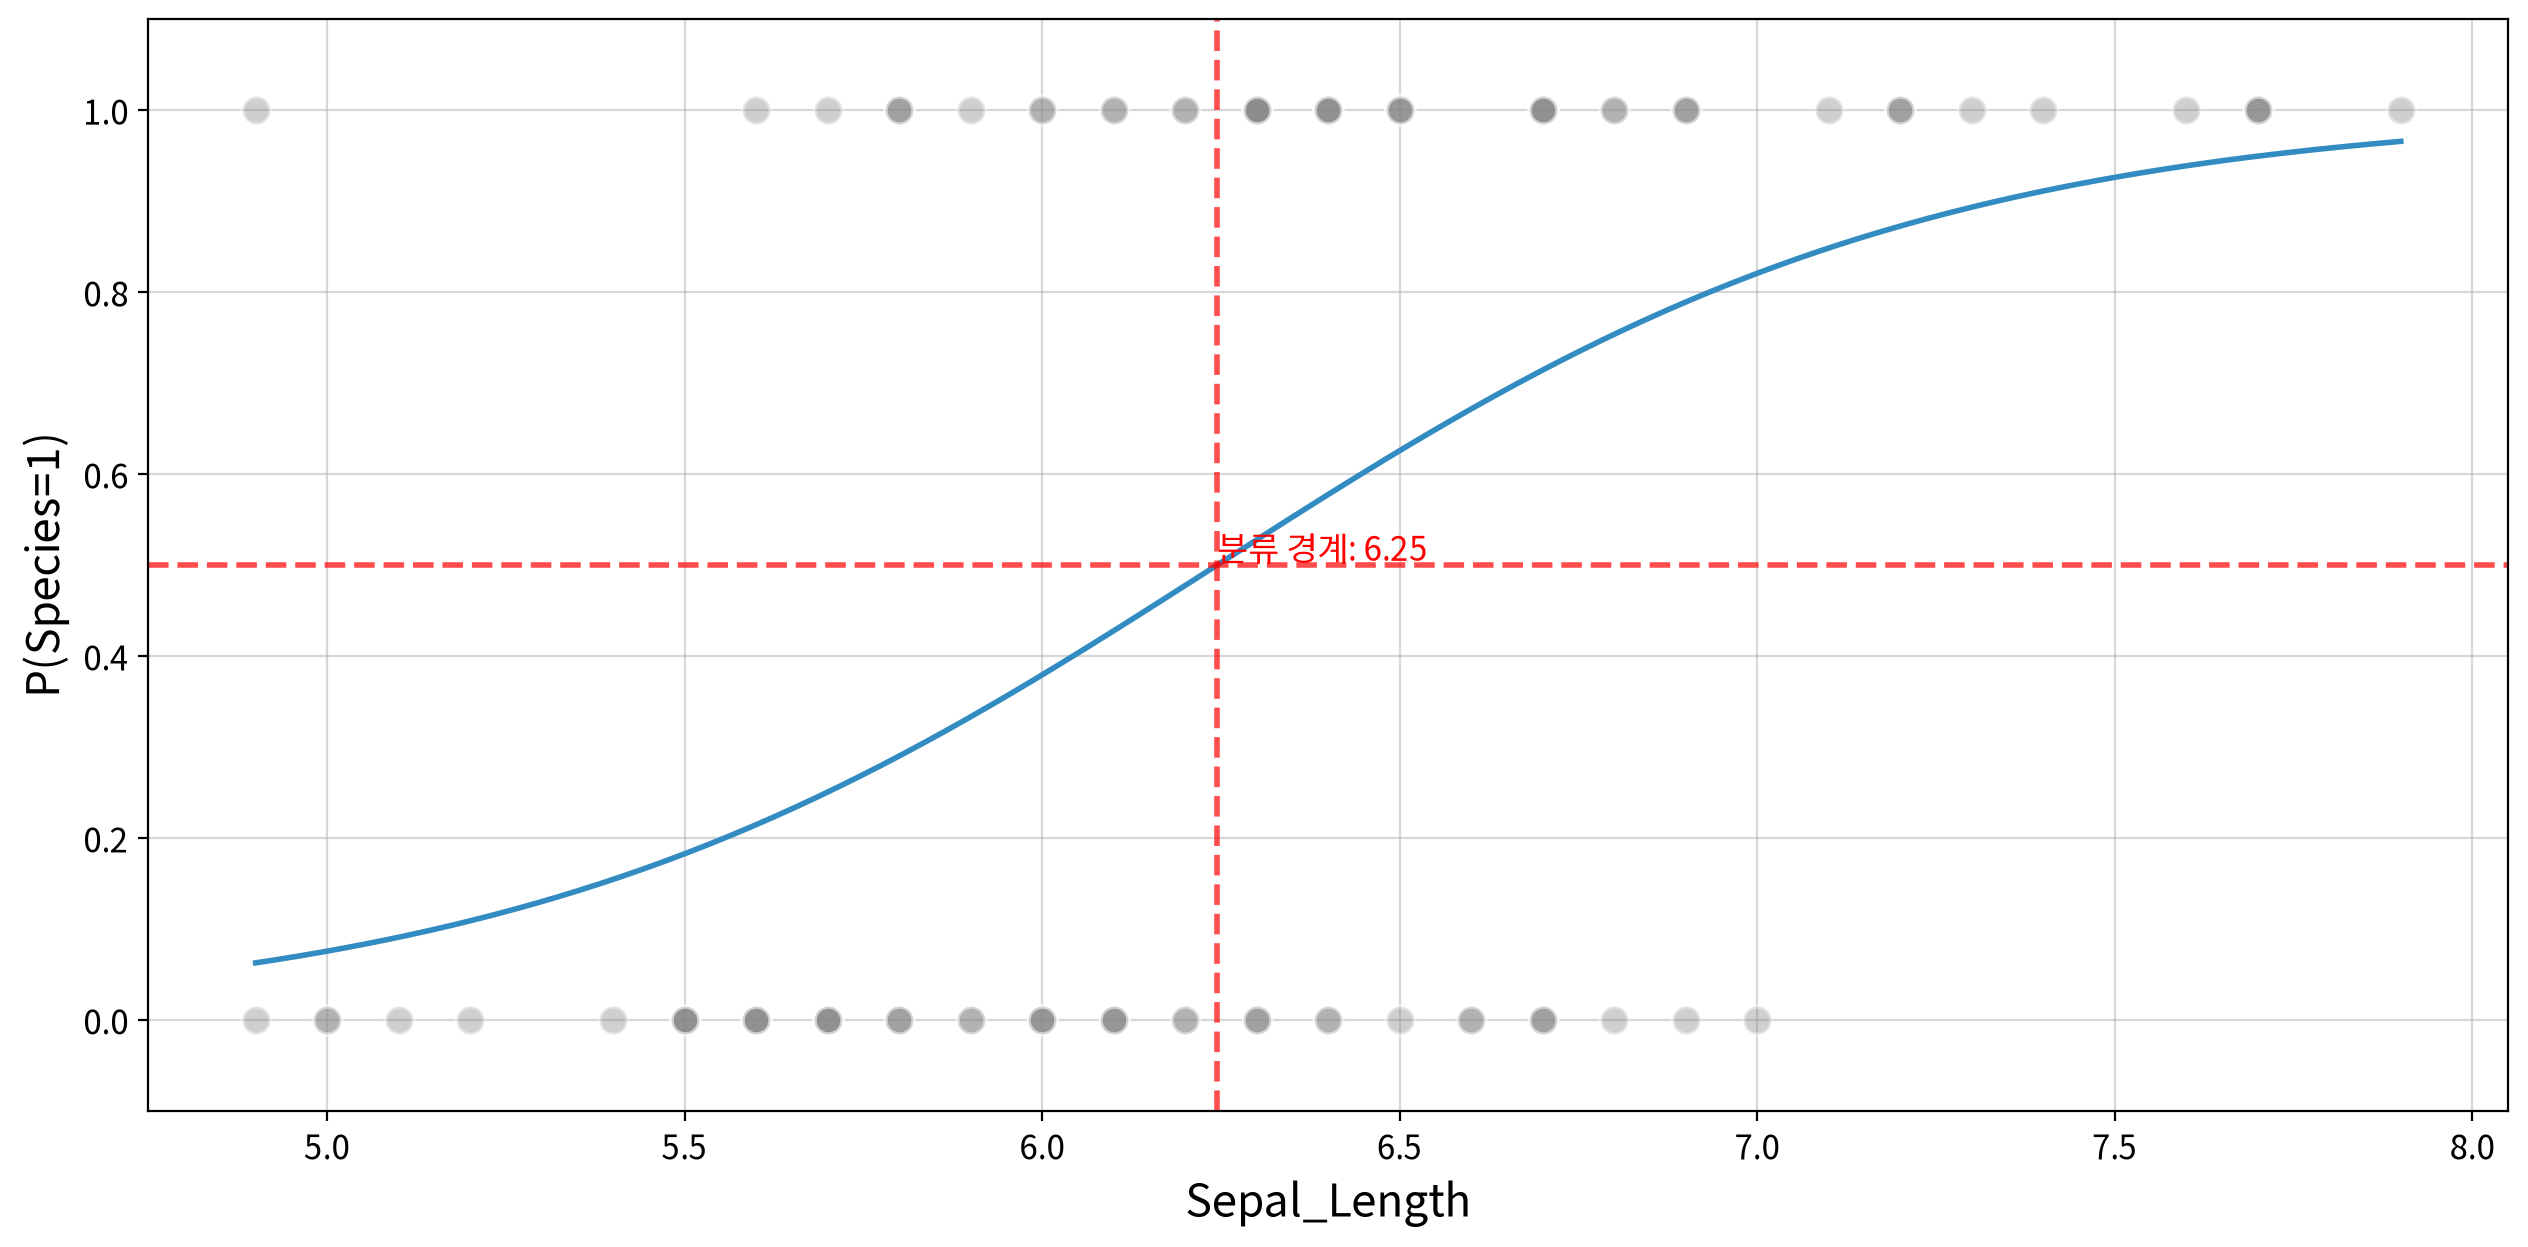

In [6]:
my_logit.plot_sigmoid(fit, new_df, x='Sepal_Length')